# Imports

In [71]:
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt
from skimage.filters import threshold_niblack, threshold_sauvola
from sklearn.metrics import confusion_matrix

In [72]:
# Preprocessing Function
def preprocess_image(image_path):
    image = cv2.imread(image_path)
    green = image[:, :, 1]  # Green channel
    
    # CLAHE
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    enhanced = clahe.apply(green)
    
    return enhanced

# Load Ground Truth
def load_mask(mask_path, fov_path):

    gt = cv2.imread(mask_path, 0)
    gt = gt > 0

    fov = cv2.imread(fov_path, 0)
    fov = fov > 0

    return gt, fov


## Why Use Green Channel? (Important)

In fundus images:

✔ Green channel shows vessels with the highest contrast  
✔ Red channel is too bright  
✔ Blue channel is too noisy  

In [73]:
image_path = "/kaggle/input/drive-digital-retinal-images-for-vessel-extraction/DRIVE/training/images/21_training.tif"
mask_path  = "/kaggle/input/drive-digital-retinal-images-for-vessel-extraction/DRIVE/training/1st_manual/21_manual1.gif"

# Load image
image = cv2.imread(image_path)
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Load ground truth
gt = cv2.imread(mask_path, 0)
gt = gt > 0   # Convert to binary

In [74]:
def apply_niblack(image, window_size=25, k=-0.2):
    thresh = threshold_niblack(image,
                               window_size=window_size,
                               k=k)
    binary = image < thresh
    return binary

In [75]:
def apply_sauvola(image, window_size=25, k=0.3):
    thresh = threshold_sauvola(image,
                               window_size=window_size,
                               k=k)
    binary = image < thresh
    return binary

In [76]:
def compute_metrics(pred, gt):
    
    # Ensure boolean
    pred = pred.astype(bool)
    gt = gt.astype(bool)

    TP = np.sum(pred & gt)
    FP = np.sum(pred & ~gt)
    FN = np.sum(~pred & gt)

    sensitivity = TP / (TP + FN + 1e-8)
    dice = (2 * TP) / (2 * TP + FP + FN + 1e-8)

    return sensitivity, dice


In [77]:
binary_niblack = apply_niblack(image_green)
binary_sauvola = apply_sauvola(image_green)

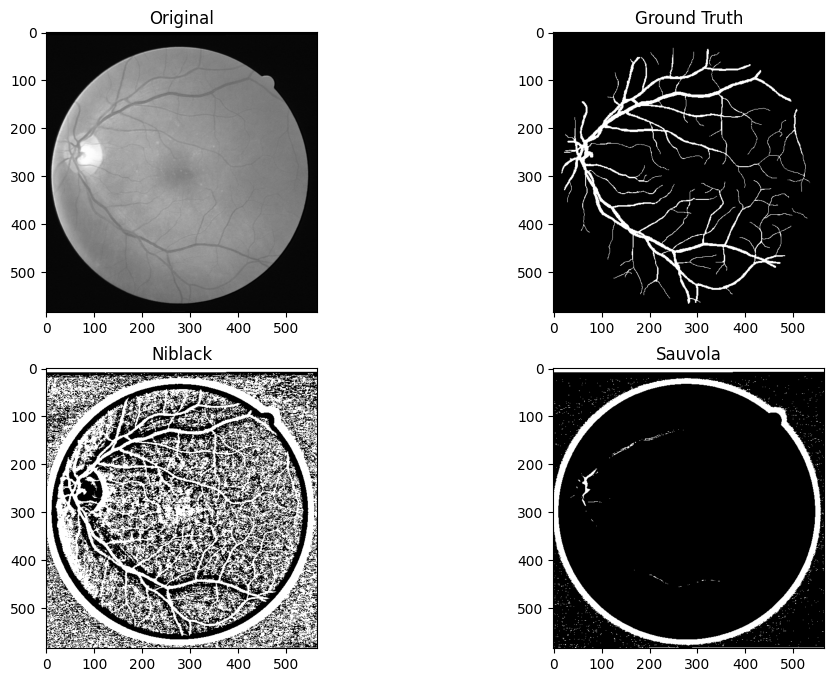

In [78]:
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.title("Original")
plt.imshow(image_gray, cmap='gray')

plt.subplot(2,2,2)
plt.title("Ground Truth")
plt.imshow(gt, cmap='gray')

plt.subplot(2,2,3)
plt.title("Niblack")
plt.imshow(binary_niblack, cmap='gray')

plt.subplot(2,2,4)
plt.title("Sauvola")
plt.imshow(binary_sauvola, cmap='gray')

plt.show()

In [79]:
sens_niblack, dice_niblack = compute_metrics(binary_niblack, gt)
sens_sauvola, dice_sauvola = compute_metrics(binary_sauvola, gt)

print("Niblack Sensitivity:", sens_niblack)
print("Niblack Dice:", dice_niblack)

print("Sauvola Sensitivity:", sens_sauvola)
print("Sauvola Dice:", dice_sauvola)

Niblack Sensitivity: 0.915808256954775
Niblack Dice: 0.21214412874071895
Sauvola Sensitivity: 0.03256549598506263
Sauvola Dice: 0.029785418869038786


## 🔎 Interpretation

### 🟥 Niblack

- Very high Sensitivity (0.91)  
- Very low Dice (0.21)

This means:
- Most vessel pixels are detected (low FN).
- But a large amount of background is also classified as vessel (high FP).

👉 This is **over-segmentation**.


### 🟦 Sauvola

- Very low Sensitivity (0.03)
- Very low Dice (0.02)

This means:
- Most vessels are missed (high FN).
- Very few pixels are predicted as vessel.

👉 This is **under-segmentation**.

## 🧠 Key Insight

Sensitivity alone is misleading.

- Niblack looks good from Sensitivity.
- But Dice reveals heavy noise.
- Sauvola is too conservative.

Both methods require parameter tuning.

In [80]:
window_sizes = [15, 21, 25]
k_values = [-0.3, -0.2, -0.1, -0.05]

best_dice = 0
best_params = None

for w in window_sizes:
    for k in k_values:

        avg_sens, avg_dice = batch_evaluate(
            image_dir,
            mask_dir,
            fov_dir,
            apply_niblack,
            window_size=w,
            k=k
        )

        print(f"Niblack → w={w}, k={k} | Sens={avg_sens:.4f}, Dice={avg_dice:.4f}")

        if avg_dice > best_dice:
            best_dice = avg_dice
            best_params = (w, k)

print("\nBest Niblack Params:", best_params)
print("Best Niblack Dice:", best_dice)

Niblack → w=15, k=-0.3 | Sens=0.9172, Dice=0.3218
Niblack → w=15, k=-0.2 | Sens=0.8987, Dice=0.3385
Niblack → w=15, k=-0.1 | Sens=0.8780, Dice=0.3559
Niblack → w=15, k=-0.05 | Sens=0.8669, Dice=0.3649
Niblack → w=21, k=-0.3 | Sens=0.9251, Dice=0.3295
Niblack → w=21, k=-0.2 | Sens=0.9071, Dice=0.3488
Niblack → w=21, k=-0.1 | Sens=0.8873, Dice=0.3690
Niblack → w=21, k=-0.05 | Sens=0.8766, Dice=0.3794
Niblack → w=25, k=-0.3 | Sens=0.9261, Dice=0.3323
Niblack → w=25, k=-0.2 | Sens=0.9083, Dice=0.3527
Niblack → w=25, k=-0.1 | Sens=0.8882, Dice=0.3740
Niblack → w=25, k=-0.05 | Sens=0.8774, Dice=0.3851

Best Niblack Params: (25, -0.05)
Best Niblack Dice: 0.38506153929823744


In [81]:
window_sizes = [15, 25, 35]
k_values = [0.2, 0.3, 0.4]

best_dice = 0
best_params = None

for w in window_sizes:
    for k in k_values:

        avg_sens, avg_dice = batch_evaluate(
            image_dir,
            mask_dir,
            fov_dir,
            apply_sauvola,
            window_size=w,
            k=k
        )

        print(f"Sauvola → w={w}, k={k} | Sens={avg_sens:.4f}, Dice={avg_dice:.4f}")

        if avg_dice > best_dice:
            best_dice = avg_dice
            best_params = (w, k)

print("\nBest Sauvola Params:", best_params)
print("Best Sauvola Dice:", best_dice)

Sauvola → w=15, k=0.2 | Sens=0.4857, Dice=0.5883
Sauvola → w=15, k=0.3 | Sens=0.3112, Dice=0.4374
Sauvola → w=15, k=0.4 | Sens=0.1854, Dice=0.2884
Sauvola → w=25, k=0.2 | Sens=0.5396, Dice=0.6186
Sauvola → w=25, k=0.3 | Sens=0.3708, Dice=0.4954
Sauvola → w=25, k=0.4 | Sens=0.2356, Dice=0.3511
Sauvola → w=35, k=0.2 | Sens=0.5578, Dice=0.6205
Sauvola → w=35, k=0.3 | Sens=0.3947, Dice=0.5139
Sauvola → w=35, k=0.4 | Sens=0.2574, Dice=0.3755

Best Sauvola Params: (35, 0.2)
Best Sauvola Dice: 0.6205295258288206


## 🔎 Why We Select Parameters Using Dice

We choose the best parameters based on **Dice score**, not Sensitivity.

Sensitivity can be high even when the model predicts too much noise.

Dice considers both false positives and false negatives, so it measures overall segmentation quality better.

Therefore, Dice is more reliable for selecting optimal parameters.

In [82]:
def batch_evaluate(image_dir, mask_dir, fov_dir,
                   threshold_function,
                   window_size=25, k=0.2):

    sensitivities = []
    dice_scores = []

    image_files = sorted(os.listdir(image_dir))

    for file in image_files:

        # Paths
        image_path = os.path.join(image_dir, file)
        mask_name = file.replace("_training.tif", "_manual1.gif")
        fov_name = file.replace("_training.tif", "_training_mask.gif")

        mask_path = os.path.join(mask_dir, mask_name)
        fov_path = os.path.join(fov_dir, fov_name)

        # Load data
        image = preprocess_image(image_path)
        gt, fov = load_mask(mask_path, fov_path)

        # Apply threshold
        pred = threshold_function(image,
                                  window_size=window_size,
                                  k=k)

        # Ensure boolean
        pred = pred.astype(bool)
        gt = gt.astype(bool)
        fov = fov.astype(bool)

        # Apply FOV mask
        pred = pred & fov
        gt = gt & fov

        # Compute metrics
        sens, dice = compute_metrics(pred, gt)

        sensitivities.append(sens)
        dice_scores.append(dice)

    avg_sens = np.mean(sensitivities)
    avg_dice = np.mean(dice_scores)

    return avg_sens, avg_dice

In [83]:
image_dir = "/kaggle/input/drive-digital-retinal-images-for-vessel-extraction/DRIVE/training/images"
mask_dir  = "/kaggle/input/drive-digital-retinal-images-for-vessel-extraction/DRIVE/training/1st_manual"
fov_dir = "/kaggle/input/drive-digital-retinal-images-for-vessel-extraction/DRIVE/training/mask"

In [84]:
avg_sens_nib, avg_dice_nib = batch_evaluate(
    image_dir,
    mask_dir,
    fov_dir, 
    apply_niblack,
    window_size=25,
    k=-0.05
)

print("Niblack → Sensitivity:", avg_sens_nib)
print("Niblack → Dice:", avg_dice_nib)


Niblack → Sensitivity: 0.8774449499089709
Niblack → Dice: 0.38506153929823744


# 📊 Niblack Result Analysis

$$
Sensitivity = \frac{TP}{TP + FN}
$$

## What it means

- Sensitivity of 0.8774 means most vessel pixels were detected.
- Dice of 0.3851 is moderate, meaning many background pixels were also wrongly detected.

## Interpretation

- The method detects vessels well (high Sensitivity).
- But it also produces noise (low Dice).
- This indicates **over-segmentation**.

## Conclusion

Niblack captures vessels effectively, but it still detects too much background.  
Further parameter tuning or post-processing is needed to improve Dice score.

In [85]:
avg_sens_sau, avg_dice_sau = batch_evaluate(
    image_dir,
    mask_dir,
    fov_dir,      
    apply_sauvola,
    window_size=35,
    k=0.2
)

print("Sauvola → Sensitivity:", avg_sens_sau)
print("Sauvola → Dice:", avg_dice_sau)

Sauvola → Sensitivity: 0.5578341805710352
Sauvola → Dice: 0.6205295258288206


# 📊 Sauvola Result Analysis

$$
Sensitivity = \frac{TP}{TP + FN}
$$

## What it means

- Sensitivity of 0.5578 means some vessels are missed.
- Dice of 0.6205 is good, meaning overall segmentation quality is balanced.

## Interpretation

- Sauvola produces less noise than Niblack.
- It avoids over-segmentation.
- The segmentation is cleaner and more stable.

## Conclusion

Sauvola provides better overall segmentation quality (higher Dice),  
even though its Sensitivity is lower than Niblack."